# RetinaFaceNET model

In [31]:
import cv2
import numpy as np
import onnxruntime as ort
import matplotlib.pyplot as plt

In [32]:
det_session = ort.InferenceSession(
    "det_500m.onnx",
    providers=["CPUExecutionProvider"]
)

det_input_name = det_session.get_inputs()[0].name

print(det_input_name)

input.1


In [33]:
def preprocess_detector(
    image_path,
    input_size=(640, 640)
):
    img = cv2.imread(image_path)

    if img is None:
        raise ValueError(f"Cannot read image: {image_path}")

    original = img.copy()

    h0, w0 = img.shape[:2]

    img = cv2.resize(img, input_size)

    rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    blob = rgb.astype(np.float32)

    blob = (blob - 127.5) / 128.0

    blob = np.transpose(blob, (2, 0, 1))

    blob = np.expand_dims(blob, axis=0)

    return blob, original, (w0, h0)

In [34]:
def generate_centers(
    fm_h,
    fm_w,
    stride,
    num_anchors=2
):
    ys, xs = np.mgrid[:fm_h, :fm_w]

    centers = np.stack(
        [xs, ys],
        axis=-1
    ).astype(np.float32)

    # SCRFD uses center offsets
    centers = (centers + 0.5) * stride

    centers = centers.reshape(-1, 2)

    centers = np.repeat(
        centers,
        num_anchors,
        axis=0
    )

    return centers

In [35]:
def distance2bbox(
    points,
    distance,
    stride
):
    x1 = points[:, 0] - distance[:, 0] * stride
    y1 = points[:, 1] - distance[:, 1] * stride

    x2 = points[:, 0] + distance[:, 2] * stride
    y2 = points[:, 1] + distance[:, 3] * stride

    return np.stack(
        [x1, y1, x2, y2],
        axis=1
    )

In [36]:
def distance2kps(
    points,
    preds,
    stride
):
    preds = preds.reshape(-1, 5, 2)

    kps = np.zeros_like(preds)

    kps[:, :, 0] = (
        points[:, None, 0]
        + preds[:, :, 0] * stride
    )

    kps[:, :, 1] = (
        points[:, None, 1]
        + preds[:, :, 1] * stride
    )

    return kps

In [37]:
def decode_scrfd(
    outputs,
    score_thresh=0.5
):
    scores_list = outputs[:3]
    bbox_list = outputs[3:6]
    kps_list = outputs[6:9]

    strides = [8, 16, 32]

    all_boxes = []
    all_scores = []
    all_kps = []

    for scores_pred, bbox_pred, kps_pred, stride in zip(
        scores_list,
        bbox_list,
        kps_list,
        strides
    ):

        fm_h = 640 // stride
        fm_w = 640 // stride

        centers = generate_centers(
            fm_h,
            fm_w,
            stride
        )

        scores = scores_pred[:, 0]

        keep = scores > score_thresh

        if keep.sum() == 0:
            continue

        centers = centers[keep]
        scores = scores[keep]

        bbox_pred = bbox_pred[keep]
        kps_pred = kps_pred[keep]

        boxes = distance2bbox(
            centers,
            bbox_pred,
            stride
        )

        kps = distance2kps(
            centers,
            kps_pred,
            stride
        )

        all_boxes.append(boxes)
        all_scores.append(scores)
        all_kps.append(kps)

    if len(all_boxes) == 0:
        return None, None, None

    boxes = np.concatenate(all_boxes)
    scores = np.concatenate(all_scores)
    kps = np.concatenate(all_kps)

    return boxes, scores, kps

In [38]:
def apply_nms(
    boxes,
    scores,
    kps,
    score_thresh=0.5,
    nms_thresh=0.4
):

    bboxes = []

    for b in boxes:
        x1, y1, x2, y2 = b

        bboxes.append([
            float(x1),
            float(y1),
            float(x2 - x1),
            float(y2 - y1)
        ])

    idxs = cv2.dnn.NMSBoxes(
        bboxes,
        scores.tolist(),
        score_thresh,
        nms_thresh
    )

    if len(idxs) == 0:
        return [], [], []

    idxs = idxs.flatten()

    return (
        boxes[idxs],
        scores[idxs],
        kps[idxs]
    )

In [40]:
image_path = "test.jpeg"

blob, original_img, original_size = preprocess_detector(
    image_path
)

outputs = det_session.run(
    None,
    {det_input_name: blob}
)

boxes, scores, kps = decode_scrfd(
    outputs,
    score_thresh=0.4
)

boxes, scores, kps = apply_nms(
    boxes,
    scores,
    kps
)

print("Faces Found:", len(boxes))

Faces Found: 2


In [41]:
orig_w, orig_h = original_size

scale_x = orig_w / 640.0
scale_y = orig_h / 640.0

boxes[:, [0, 2]] *= scale_x
boxes[:, [1, 3]] *= scale_y

kps[:, :, 0] *= scale_x
kps[:, :, 1] *= scale_y

In [42]:
draw_img = original_img.copy()

for box, score, landmarks in zip(
    boxes,
    scores,
    kps
):

    x1, y1, x2, y2 = box.astype(int)

    cv2.rectangle(
        draw_img,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    for p in landmarks.astype(int):

        cv2.circle(
            draw_img,
            tuple(p),
            2,
            (0, 0, 255),
            -1
        )

    cv2.putText(
        draw_img,
        f"{score:.2f}",
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )

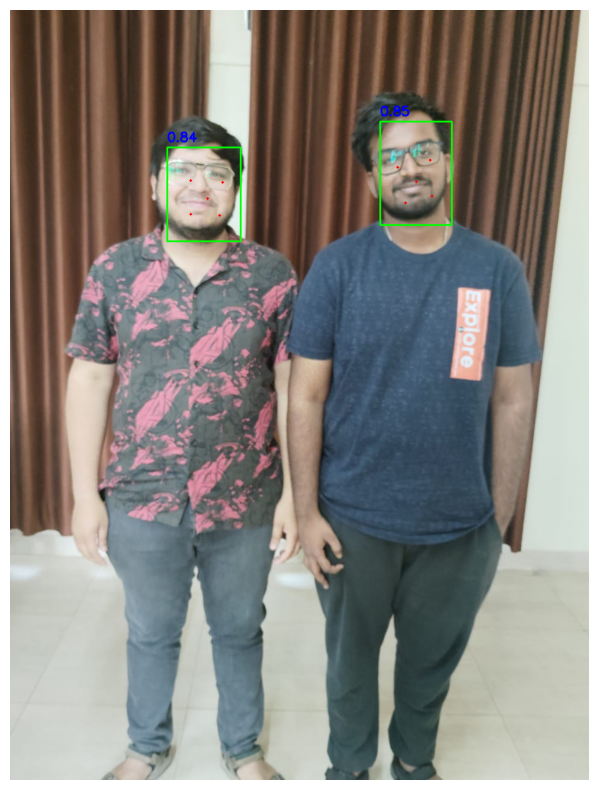

In [43]:
cv2.imwrite(
    "detections.jpg",
    draw_img
)

plt.figure(figsize=(10,10))

plt.imshow(
    cv2.cvtColor(
        draw_img,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")
plt.show()

# Load Recognition Model

In [45]:
rec_session = ort.InferenceSession(
    "w600k_mbf.onnx",
    providers=["CPUExecutionProvider"]
)

rec_input_name = rec_session.get_inputs()[0].name

In [46]:
def preprocess_face(face):

    face = cv2.resize(
        face,
        (112,112)
    )

    face = cv2.cvtColor(
        face,
        cv2.COLOR_BGR2RGB
    )

    face = face.astype(np.float32)

    face = (face - 127.5) / 128.0

    face = np.transpose(
        face,
        (2,0,1)
    )

    face = np.expand_dims(
        face,
        axis=0
    )

    return face

In [47]:
embeddings = []

for box in boxes:

    x1, y1, x2, y2 = box.astype(int)

    face = original_img[
        max(0,y1):min(original_img.shape[0],y2),
        max(0,x1):min(original_img.shape[1],x2)
    ]

    if face.size == 0:
        continue

    face_blob = preprocess_face(face)

    embedding = rec_session.run(
        None,
        {rec_input_name: face_blob}
    )[0]

    embeddings.append(embedding[0])

print("Embeddings:", len(embeddings))
print("Embedding Shape:", embeddings[0].shape)

Embeddings: 2
Embedding Shape: (512,)
